# 🏪 AI-Powered Sales Data Analytics and Business Insights

---

| Field | Details |
|-------|---------|
| **Student** | Dharv Patel |
| **Program** | IBM SkillsBuild Data Analytics with AI Internship 2026 |
| **Organisation** | BharatCares / AICTE / IBM SkillsBuild |
| **Project Type** | Data Analytics + Artificial Intelligence / Machine Learning |
| **Notebook** | DharvPatel_AI_Sales_Analytics.ipynb |

---


## 1. Project Overview

This project presents an **end-to-end data analytics solution** for analysing retail
sales data. We clean and explore a synthetic Superstore-style sales dataset, create
meaningful visualisations, discover actionable business insights, and apply machine
learning to predict future sales.

The project is structured to mirror a real-world business analytics workflow:
data ingestion → cleaning → EDA → visualisation → ML modelling → business insights.

**Dataset Note:** The dataset used in this project is a synthetic sales dataset
generated using Python for educational and internship demonstration purposes.
It is modelled after publicly available Superstore-style retail datasets
(reference: https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset)
but is not sourced from any real company.


## 2. Problem Statement

Retail businesses generate vast amounts of transactional data daily, but actionable
insights are rarely extracted efficiently. Management teams struggle to:

- Identify which products, categories, and regions drive the most revenue.
- Understand seasonal demand patterns.
- Quantify how discount strategies affect profitability.
- Forecast future sales to plan inventory and resources.

This project addresses these challenges by applying data analytics and AI/ML
techniques to a comprehensive sales dataset, transforming raw data into
measurable business intelligence.


## 3. Objectives

1. Load, inspect, and clean the sales dataset.
2. Perform comprehensive exploratory data analysis (EDA).
3. Create professional, insight-driven visualisations.
4. Answer critical business questions from the data.
5. Engineer meaningful features for machine learning.
6. Train and evaluate multiple ML regression models for sales prediction.
7. Generate AI-assisted, rule-based business insights from actual results.
8. Provide actionable business recommendations.


## 4. Scope of the Project

| In Scope | Out of Scope |
|----------|-------------|
| Sales trend analysis | Real-time data ingestion |
| Product & category performance | Live API integration |
| Regional & segment analysis | Customer churn prediction |
| Discount impact study | Deep-learning models |
| ML-based sales prediction | Deployment to production |
| Rule-based AI business insights | External LLM API calls |


## 5. Technologies Used

| Technology | Purpose |
|------------|---------|
| Python 3 | Primary programming language |
| Jupyter Notebook | Interactive analysis environment |
| Pandas | Data manipulation and analysis |
| NumPy | Numerical computing |
| Matplotlib | Static charting and visualisation |
| Seaborn | Statistical data visualisation |
| Scikit-learn | Machine learning models and evaluation |
| python-docx | Project report generation |


## 6. Dataset Description

**Dataset:** Synthetic Superstore Sales Dataset  
**Source:** Synthetically generated using Python (reference structure: [Kaggle Superstore Sales Dataset](https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset))  
**Records:** 10,000 rows  
**Columns:** 18 features  
**Time Period:** January 2021 – December 2023  

| Column | Type | Description |
|--------|------|-------------|
| Order_ID | String | Unique order identifier |
| Order_Date | Date | Date the order was placed |
| Ship_Date | Date | Date the order was shipped |
| Ship_Mode | String | Shipping mode selected |
| Customer_ID | String | Unique customer identifier |
| Customer_Name | String | Name of the customer |
| Segment | String | Customer segment (Consumer/Corporate/Home Office) |
| Region | String | Geographic region (East/West/Central/South) |
| State | String | City/state of delivery |
| Category | String | Product category (Technology/Furniture/Office Supplies) |
| Sub_Category | String | Product sub-category |
| Product_Name | String | Product description |
| Quantity | Integer | Units ordered |
| Unit_Price | Float | Price per unit in USD |
| Discount | Float | Discount rate applied (0.0 – 0.5) |
| Sales | Float | Net sales amount in USD |
| Profit | Float | Profit earned in USD |
| Payment_Method | String | Payment method used |


## 7. Import Libraries

In [1]:
# Standard library
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="viridis")

print("✅ All libraries imported successfully.")
print(f"   Pandas  : {pd.__version__}")
print(f"   NumPy   : {np.__version__}")
print(f"   Sklearn : {__import__('sklearn').__version__}")


✅ All libraries imported successfully.
   Pandas  : 3.0.3
   NumPy   : 2.4.6
   Sklearn : 1.8.0


## 8. Load Dataset

We load the synthetic sales dataset from the `data/` folder.


In [2]:
# Locate the data file relative to this notebook
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
DATA_PATH = os.path.join(NOTEBOOK_DIR, "..", "data", "sales_data.csv")

# Fallback: try same directory
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join(NOTEBOOK_DIR, "sales_data.csv")

df_raw = pd.read_csv(DATA_PATH, parse_dates=["Order_Date", "Ship_Date"])
print(f"✅ Dataset loaded successfully from: {os.path.abspath(DATA_PATH)}")


✅ Dataset loaded successfully from: C:\Users\DHARV\Desktop\IBM AI for Data Analysis\AI-Sales-Analytics\data\sales_data.csv


## 9. Initial Data Inspection

Before any analysis, we inspect the raw dataset to understand its structure, 
data types, and initial quality.


In [3]:
print("=" * 55)
print("  INITIAL DATA INSPECTION")
print("=" * 55)

print(f"\n📐 Shape (rows × columns): {df_raw.shape}")


  INITIAL DATA INSPECTION

📐 Shape (rows × columns): (10000, 18)


In [4]:
print("\n📋 Column Names:")
print(list(df_raw.columns))



📋 Column Names:
['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Region', 'State', 'Category', 'Sub_Category', 'Product_Name', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method']


In [5]:
print("\n🔎 Data Types:")
print(df_raw.dtypes)



🔎 Data Types:
Order_ID                     str
Order_Date        datetime64[us]
Ship_Date         datetime64[us]
Ship_Mode                    str
Customer_ID                  str
Customer_Name                str
Segment                      str
Region                       str
State                        str
Category                     str
Sub_Category                 str
Product_Name                 str
Quantity                   int64
Unit_Price               float64
Discount                 float64
Sales                    float64
Profit                   float64
Payment_Method               str
dtype: object


In [6]:
print("\n📊 First 5 Rows:")
df_raw.head()



📊 First 5 Rows:


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Region,State,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method
0,ORD-08913,2021-01-01,2021-01-05,Second Class,CUST-0122,Patricia Robinson,Corporate,West,San Francisco,Technology,Computers,Lenovo ThinkPad X1 Carbon,7,1426.51,0.30,5242.42,792.59,Cheque
1,ORD-02614,2021-01-01,2021-01-06,Standard Class,CUST-0999,Mary Thompson,Corporate,South,Atlanta,Furniture,Chairs,Serta Big & Tall Chair,4,353.82,0.10,955.31,83.64,Online Transfer
2,ORD-01226,2021-01-01,2021-01-01,Same Day,CUST-0488,Patricia Johnson,Home Office,Central,Houston,Furniture,Furnishings,Fellowes Shredder,1,142.15,0.30,74.63,5.13,COD
3,ORD-06706,2021-01-01,2021-01-01,Same Day,CUST-1323,Linda Joshi,Consumer,East,Boston,Office Supplies,Fasteners,Swingline Standard Staples 5000ct,2,9.72,0.00,14.58,4.24,Credit Card
4,ORD-00959,2021-01-01,2021-01-04,Second Class,CUST-1256,Barbara Anderson,Home Office,East,New York,Furniture,Tables,Autonomous SmartDesk Pro,3,697.34,0.20,1255.21,105.23,Debit Card


In [7]:
print("\n📊 Last 5 Rows:")
df_raw.tail()



📊 Last 5 Rows:


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Region,State,Category,Sub_Category,Product_Name,Quantity,Unit_Price,Discount,Sales,Profit,Payment_Method
9995,ORD-01504,2023-12-30,2024-01-01,First Class,CUST-0021,Ananya Gupta,Home Office,West,Sacramento,Furniture,Chairs,IKEA Markus Office Chair,6,218.01,0.00,1765.88,172.58,Credit Card
9996,ORD-04023,2023-12-30,2023-12-30,Same Day,CUST-0445,Michael Thomas,Consumer,West,Sacramento,Furniture,Bookcases,Bush Business 5-Shelf Bookcase,1,269.08,0.10,326.93,38.82,Online Transfer
9997,ORD-02376,2023-12-31,2024-01-03,Second Class,CUST-1277,Rohan Robinson,Home Office,West,Portland,Furniture,Bookcases,Ameriwood Home Logan Bookcase,2,148.99,0.50,201.14,9.93,Credit Card
9998,ORD-05540,2023-12-31,2024-01-07,Standard Class,CUST-1279,James Taylor,Corporate,West,Portland,Office Supplies,Envelopes,Columbian Kraft Envelopes 100ct,1,13.91,0.00,18.78,7.66,Cheque
9999,ORD-07198,2023-12-31,2024-01-01,First Class,CUST-0647,Sneha Shah,Home Office,East,Bridgeport,Furniture,Chairs,Hon Ignition 2.0 Chair,1,508.73,0.40,412.07,29.23,Cheque


In [8]:
print("\n❓ Missing Values per Column:")
missing = df_raw.isnull().sum()
print(missing[missing >= 0].to_string())



❓ Missing Values per Column:
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Region            0
State             0
Category          0
Sub_Category      0
Product_Name      0
Quantity          0
Unit_Price        0
Discount          0
Sales             0
Profit            0
Payment_Method    0


In [9]:
print(f"\n🔁 Duplicate Rows: {df_raw.duplicated().sum()}")



🔁 Duplicate Rows: 0


In [10]:
print("\n📈 Basic Statistical Summary (Numerical Columns):")
df_raw.describe()



📈 Basic Statistical Summary (Numerical Columns):


,Order_Date,Ship_Date,Quantity,Unit_Price,Discount,Sales,Profit
count,10000,10000,10000.00,10000.00,10000.00,10000.00,10000.00
mean,2022-06-28 20:44:35.520000,2022-07-01 07:52:45.120000,2.45,350.42,0.16,681.81,107.39
min,2021-01-01 00:00:00,2021-01-01 00:00:00,1.00,6.43,0.00,2.64,0.43
25%,2021-09-22 00:00:00,2021-09-25 00:00:00,1.00,27.92,0.00,45.99,9.12
50%,2022-06-29 00:00:00,2022-07-01 00:00:00,2.00,166.79,0.15,228.96,27.81
75%,2023-04-02 00:00:00,2023-04-05 00:00:00,3.00,514.93,0.30,812.97,104.13
max,2023-12-31 00:00:00,2024-01-07 00:00:00,8.00,1618.04,0.50,15144.84,4010.78
std,NaN,NaN,1.68,426.26,0.16,1163.02,215.71


In [11]:
print("\n📋 Categorical Columns – Unique Value Counts:")
cat_cols = df_raw.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"  {col}: {df_raw[col].nunique()} unique values  → {df_raw[col].unique()[:5].tolist()} ...")



📋 Categorical Columns – Unique Value Counts:
  Order_ID: 10000 unique values  → ['ORD-08913', 'ORD-02614', 'ORD-01226', 'ORD-06706', 'ORD-00959'] ...
  Ship_Mode: 4 unique values  → ['Second Class', 'Standard Class', 'Same Day', 'First Class'] ...
  Customer_ID: 1498 unique values  → ['CUST-0122', 'CUST-0999', 'CUST-0488', 'CUST-1323', 'CUST-1256'] ...
  Customer_Name: 716 unique values  → ['Patricia Robinson', 'Mary Thompson', 'Patricia Johnson', 'Linda Joshi', 'Barbara Anderson'] ...
  Segment: 3 unique values  → ['Corporate', 'Home Office', 'Consumer'] ...
  Region: 4 unique values  → ['West', 'South', 'Central', 'East'] ...
  State: 40 unique values  → ['San Francisco', 'Atlanta', 'Houston', 'Boston', 'New York'] ...
  Category: 3 unique values  → ['Technology', 'Furniture', 'Office Supplies'] ...
  Sub_Category: 16 unique values  → ['Computers', 'Chairs', 'Furnishings', 'Fasteners', 'Tables'] ...
  Product_Name: 80 unique values  → ['Lenovo ThinkPad X1 Carbon', 'Serta Big & Tall 

## 10. Data Understanding

### Key Observations

After initial inspection:
- The dataset contains **18 columns** covering order information, product details, geography, and financials.
- **Order_Date** and **Ship_Date** are already parsed as datetime types.
- The **Sales** column represents net revenue (after discount) — this is our primary financial metric.
- **Profit** can be negative for heavily discounted orders.
- **Discount** ranges from 0 (no discount) to 0.5 (50% off).
- No missing values are expected since the data is synthetically generated, but we verify this rigorously below.
- Categorical columns include: Segment, Region, Category, Sub_Category, Ship_Mode, Payment_Method.

### Business Questions This Data Can Answer:
1. Which products, categories, and regions generate the most revenue?
2. How do discounts affect profitability?
3. What are the seasonal sales patterns?
4. Can we predict future sales using ML?


## 11. Data Cleaning

Thorough data cleaning ensures the reliability of our analysis. 
We check for and handle:
- Missing values
- Duplicate records
- Data type correctness
- Date validity
- Invalid numeric values (negative sales, impossible discounts)
- Basic consistency checks


In [12]:
df = df_raw.copy()
print("Working copy created. Shape:", df.shape)


Working copy created. Shape: (10000, 18)


In [13]:
# ── 1. Missing Values ─────────────────────────────────────────────────────
print("STEP 1: Missing Value Analysis")
print("-" * 40)
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing_count, "Percentage (%)": missing_pct})
print(missing_df)
print(f"\nTotal missing values: {missing_count.sum()}")

if missing_count.sum() == 0:
    print("✅ No missing values found.")
else:
    print("⚠️  Handling missing values...")
    # Fill numeric columns with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    # Fill categorical with mode
    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    print("✅ Missing values handled.")


STEP 1: Missing Value Analysis
----------------------------------------
                Count  Percentage (%)
Order_ID            0            0.00
Order_Date          0            0.00
Ship_Date           0            0.00
Ship_Mode           0            0.00
Customer_ID         0            0.00
Customer_Name       0            0.00
Segment             0            0.00
Region              0            0.00
State               0            0.00
Category            0            0.00
Sub_Category        0            0.00
Product_Name        0            0.00
Quantity            0            0.00
Unit_Price          0            0.00
Discount            0            0.00
Sales               0            0.00
Profit              0            0.00
Payment_Method      0            0.00

Total missing values: 0
✅ No missing values found.


In [14]:
# ── 2. Duplicate Detection & Removal ────────────────────────────────────────
print("STEP 2: Duplicate Detection")
print("-" * 40)
dups_before = df.duplicated().sum()
print(f"Duplicate rows found: {dups_before}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"✅ Duplicates removed. Shape after removal: {df.shape}")


STEP 2: Duplicate Detection
----------------------------------------


Duplicate rows found: 0

✅ Duplicates removed. Shape after removal: (10000, 18)


In [15]:
# ── 3. Data Type Verification ────────────────────────────────────────────────
print("STEP 3: Data Type Verification")
print("-" * 40)
print(df.dtypes)

# Ensure date columns are datetime
for col in ["Order_Date", "Ship_Date"]:
    if not pd.api.types.is_datetime64_any_dtype(df[col]):
        df[col] = pd.to_datetime(df[col])
        print(f"  Converted '{col}' to datetime.")
    else:
        print(f"  ✅ '{col}' is already datetime.")


STEP 3: Data Type Verification
----------------------------------------
Order_ID                     str
Order_Date        datetime64[us]
Ship_Date         datetime64[us]
Ship_Mode                    str
Customer_ID                  str
Customer_Name                str
Segment                      str
Region                       str
State                        str
Category                     str
Sub_Category                 str
Product_Name                 str
Quantity                   int64
Unit_Price               float64
Discount                 float64
Sales                    float64
Profit                   float64
Payment_Method               str
dtype: object
  ✅ 'Order_Date' is already datetime.
  ✅ 'Ship_Date' is already datetime.


In [16]:
# ── 4. Invalid Value Detection ──────────────────────────────────────────────
print("STEP 4: Invalid Value Detection")
print("-" * 40)

# Sales should be positive
neg_sales = (df["Sales"] <= 0).sum()
print(f"  Negative/zero Sales values: {neg_sales}")

# Quantity should be positive integer
neg_qty = (df["Quantity"] <= 0).sum()
print(f"  Non-positive Quantity values: {neg_qty}")

# Discount should be between 0 and 1
invalid_disc = ((df["Discount"] < 0) | (df["Discount"] > 1)).sum()
print(f"  Out-of-range Discount values (not in [0,1]): {invalid_disc}")

# Ship_Date must be >= Order_Date
invalid_dates = (df["Ship_Date"] < df["Order_Date"]).sum()
print(f"  Orders where Ship_Date < Order_Date: {invalid_dates}")

# Remove any records where Ship_Date < Order_Date
if invalid_dates > 0:
    df = df[df["Ship_Date"] >= df["Order_Date"]].copy()
    print(f"  ✅ Invalid date records removed. Shape: {df.shape}")
else:
    print("  ✅ All date relationships are valid.")

print(f"\n✅ Data cleaning complete. Clean dataset shape: {df.shape}")


STEP 4: Invalid Value Detection
----------------------------------------
  Negative/zero Sales values: 0
  Non-positive Quantity values: 0
  Out-of-range Discount values (not in [0,1]): 0
  Orders where Ship_Date < Order_Date: 0
  ✅ All date relationships are valid.

✅ Data cleaning complete. Clean dataset shape: (10000, 18)


STEP 5: Outlier Analysis (IQR Method)
----------------------------------------


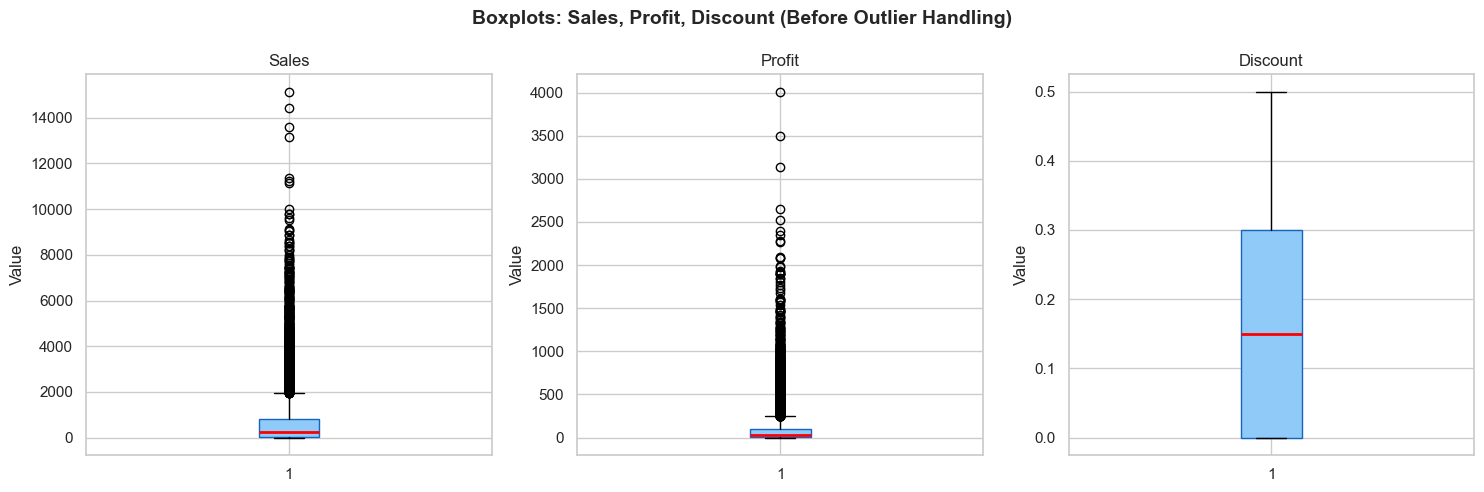

  Sales: 947 potential outliers (IQR method) — kept for realistic analysis
  Profit: 1225 potential outliers (IQR method) — kept for realistic analysis


In [17]:
# ── 5. Outlier Analysis ──────────────────────────────────────────────────────
print("STEP 5: Outlier Analysis (IQR Method)")
print("-" * 40)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Boxplots: Sales, Profit, Discount (Before Outlier Handling)", fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["Sales", "Profit", "Discount"]):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor="#90CAF9", color="#1565C0"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

# IQR-based outlier count (we keep outliers but flag them)
for col in ["Sales", "Profit"]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 1.5 * IQR
    hi  = Q3 + 1.5 * IQR
    outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"  {col}: {outliers} potential outliers (IQR method) — kept for realistic analysis")


In [18]:
print("\n✅ Data Cleaning Summary:")
print(f"   Original records  : {len(df_raw):,}")
print(f"   Clean records     : {len(df):,}")
print(f"   Records removed   : {len(df_raw) - len(df):,}")
print(f"   Missing values    : {df.isnull().sum().sum()}")
print(f"   Duplicate rows    : {df.duplicated().sum()}")



✅ Data Cleaning Summary:
   Original records  : 10,000
   Clean records     : 10,000
   Records removed   : 0
   Missing values    : 0
   Duplicate rows    : 0


## 12. Data Preprocessing

After cleaning, we prepare the data for analysis. Preprocessing involves 
standardising formats and ensuring consistency across the dataset.


In [19]:
# Ensure string columns are stripped of whitespace
str_cols = df.select_dtypes(include="object").columns
for col in str_cols:
    df[col] = df[col].str.strip()

# Ensure Category values are valid
valid_cats = {"Technology", "Furniture", "Office Supplies"}
invalid_cat_mask = ~df["Category"].isin(valid_cats)
print(f"Invalid Category values: {invalid_cat_mask.sum()}")

# Verify discount range
df["Discount"] = df["Discount"].clip(0, 1)

print("\n✅ Preprocessing complete.")
print(df.dtypes)


Invalid Category values: 0

✅ Preprocessing complete.
Order_ID                     str
Order_Date        datetime64[us]
Ship_Date         datetime64[us]
Ship_Mode                    str
Customer_ID                  str
Customer_Name                str
Segment                      str
Region                       str
State                        str
Category                     str
Sub_Category                 str
Product_Name                 str
Quantity                   int64
Unit_Price               float64
Discount                 float64
Sales                    float64
Profit                   float64
Payment_Method               str
dtype: object


## 13. Feature Engineering

We create new derived features to enable deeper analysis:

| Feature | Formula | Purpose |
|---------|---------|---------|
| `Year` | `Order_Date.year` | Year-level trend analysis |
| `Month` | `Order_Date.month` | Seasonality analysis |
| `Month_Name` | `Order_Date.strftime('%b')` | Readable month labels |
| `Quarter` | `Order_Date.quarter` | Quarterly grouping |
| `Profit_Margin` | `Profit / Sales × 100` | Product/category profitability |
| `Discount_Amount` | `Unit_Price × Quantity × Discount` | Absolute discount value |
| `Revenue` | Alias for `Sales` | Clarity in reporting |


In [20]:
df["Year"]            = df["Order_Date"].dt.year
df["Month"]           = df["Order_Date"].dt.month
df["Month_Name"]      = df["Order_Date"].dt.strftime("%b")
df["Quarter"]         = df["Order_Date"].dt.quarter
df["Profit_Margin"]   = (df["Profit"] / df["Sales"].replace(0, np.nan) * 100).round(2)
df["Discount_Amount"] = (df["Unit_Price"] * df["Quantity"] * df["Discount"]).round(2)
df["Revenue"]         = df["Sales"]

print("✅ Feature engineering complete.")
print("\nNew columns added:", ["Year", "Month", "Month_Name", "Quarter",
                                "Profit_Margin", "Discount_Amount", "Revenue"])
df[["Order_Date", "Year", "Month", "Month_Name", "Quarter",
    "Sales", "Profit", "Profit_Margin", "Discount_Amount"]].head(5)


✅ Feature engineering complete.

New columns added: ['Year', 'Month', 'Month_Name', 'Quarter', 'Profit_Margin', 'Discount_Amount', 'Revenue']


,Order_Date,Year,Month,Month_Name,Quarter,Sales,Profit,Profit_Margin,Discount_Amount
0,2021-01-01,2021,1,Jan,1,5242.42,792.59,15.12,2995.67
1,2021-01-01,2021,1,Jan,1,955.31,83.64,8.76,141.53
2,2021-01-01,2021,1,Jan,1,74.63,5.13,6.87,42.64
3,2021-01-01,2021,1,Jan,1,14.58,4.24,29.08,0.00
4,2021-01-01,2021,1,Jan,1,1255.21,105.23,8.38,418.40


## 14. Exploratory Data Analysis (EDA)

EDA helps us understand the distribution, relationships, and patterns in the data.
We calculate key business KPIs and analyse performance across multiple dimensions.


### 14.1 Key Performance Indicators (KPIs)

In [21]:
# ── KPIs ─────────────────────────────────────────────────────────────────────
total_revenue  = df["Sales"].sum()
total_profit   = df["Profit"].sum()
total_orders   = df["Order_ID"].nunique()
total_qty      = df["Quantity"].sum()
avg_order_val  = df["Sales"].mean()
avg_profit     = df["Profit"].mean()
avg_discount   = df["Discount"].mean() * 100
overall_margin = df["Profit"].sum() / df["Sales"].sum() * 100

print("=" * 50)
print("       KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 50)
print(f"  Total Revenue         : ${total_revenue:>14,.2f}")
print(f"  Total Profit          : ${total_profit:>14,.2f}")
print(f"  Total Orders          : {total_orders:>15,}")
print(f"  Total Quantity Sold   : {total_qty:>15,}")
print(f"  Average Order Value   : ${avg_order_val:>14,.2f}")
print(f"  Average Profit/Order  : ${avg_profit:>14,.2f}")
print(f"  Average Discount      : {avg_discount:>14.2f}%")
print(f"  Overall Profit Margin : {overall_margin:>14.2f}%")
print("=" * 50)


       KEY PERFORMANCE INDICATORS (KPIs)
  Total Revenue         : $  6,818,142.45
  Total Profit          : $  1,073,903.31
  Total Orders          :          10,000
  Total Quantity Sold   :          24,492
  Average Order Value   : $        681.81
  Average Profit/Order  : $        107.39
  Average Discount      :          16.37%
  Overall Profit Margin :          15.75%


### 14.2 Sales by Year

In [22]:
yearly = df.groupby("Year")[["Sales", "Profit"]].sum().reset_index()
yearly["Profit_Margin_%"] = (yearly["Profit"] / yearly["Sales"] * 100).round(2)
yearly["Sales"] = yearly["Sales"].round(2)
yearly["Profit"] = yearly["Profit"].round(2)
print("Yearly Sales & Profit Summary:")
yearly


Yearly Sales & Profit Summary:


,Year,Sales,Profit,Profit_Margin_%
0,2021,2306333.72,357102.14,15.48
1,2022,2227887.88,350667.23,15.74
2,2023,2283920.85,366133.94,16.03


### 14.3 Sales by Category

In [23]:
cat_summary = df.groupby("Category").agg(
    Total_Revenue=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Orders=("Order_ID", "count"),
    Avg_Discount=("Discount", "mean"),
).round(2)
cat_summary["Profit_Margin_%"] = (cat_summary["Total_Profit"] / cat_summary["Total_Revenue"] * 100).round(2)
cat_summary = cat_summary.sort_values("Total_Revenue", ascending=False)
print("Category Performance Summary:")
cat_summary


Category Performance Summary:


,Total_Revenue,Total_Profit,Total_Orders,Avg_Discount,Profit_Margin_%
Category,,,,,
Technology,4090194.29,802207.17,3314,0.17,19.61
Furniture,2581860.60,232090.46,3314,0.17,8.99
Office Supplies,146087.56,39605.68,3372,0.16,27.11


### 14.4 Sales by Region

In [24]:
region_summary = df.groupby("Region").agg(
    Total_Revenue=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Orders=("Order_ID", "count"),
).round(2)
region_summary["Profit_Margin_%"] = (region_summary["Total_Profit"] / region_summary["Total_Revenue"] * 100).round(2)
region_summary = region_summary.sort_values("Total_Revenue", ascending=False)
print("Regional Performance Summary:")
region_summary


Regional Performance Summary:

,Total_Revenue,Total_Profit,Total_Orders,Profit_Margin_%
Region,,,,
South,1747085.95,273300.30,2524,15.64
Central,1742823.54,281338.50,2490,16.14
West,1681813.38,269302.59,2555,16.01
East,1646419.58,249961.92,2431,15.18


### 14.5 Sales by Segment

In [25]:
seg_summary = df.groupby("Segment").agg(
    Total_Revenue=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Orders=("Order_ID", "count"),
).round(2)
seg_summary["Profit_Margin_%"] = (seg_summary["Total_Profit"] / seg_summary["Total_Revenue"] * 100).round(2)
print("Segment Performance Summary:")
seg_summary


Segment Performance Summary:


,Total_Revenue,Total_Profit,Total_Orders,Profit_Margin_%
Segment,,,,
Consumer,2313498.80,361488.83,3377,15.63
Corporate,2269996.98,351518.67,3266,15.49
Home Office,2234646.67,360895.81,3357,16.15


### 14.6 Sub-Category Performance

In [26]:
subcat = df.groupby(["Category", "Sub_Category"]).agg(
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "count"),
).round(2)
subcat["Profit_Margin_%"] = (subcat["Profit"] / subcat["Revenue"] * 100).round(2)
subcat = subcat.sort_values("Revenue", ascending=False)
print("Sub-Category Performance (Top 15):")
subcat.head(15)


Sub-Category Performance (Top 15):

,,Revenue,Profit,Orders,Profit_Margin_%
Category,Sub_Category,,,,
Technology,Computers,2117232.88,414051.23,833,19.56
Furniture,Chairs,1271700.80,116204.06,832,9.14
Technology,Phones,1158353.78,228310.75,850,19.71
Furniture,Tables,844496.54,74851.74,856,8.86
Technology,Copiers,587901.55,115654.35,793,19.67
Furniture,Bookcases,277826.06,24690.93,798,8.89
Technology,Accessories,226706.08,44190.84,838,19.49
Furniture,Furnishings,187837.20,16343.73,828,8.70
Office Supplies,Storage,40759.27,11253.06,446,27.61


### 14.7 Monthly Sales Summary

In [27]:
month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby(["Year", "Month", "Month_Name"]).agg(
    Revenue=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order_ID", "count"),
).round(2).reset_index()
monthly = monthly.sort_values(["Year","Month"])
print("Monthly Sales (first 12 rows):")
monthly.head(12)


Monthly Sales (first 12 rows):


,Year,Month,Month_Name,Revenue,Profit,Orders
0,2021,1,Jan,166428.45,27467.38,288
1,2021,2,Feb,159369.26,26440.66,271
2,2021,3,Mar,200350.98,28901.94,291
3,2021,4,Apr,230497.39,35379.79,308
4,2021,5,May,211947.72,32735.21,288
5,2021,6,Jun,166883.92,25361.02,289
6,2021,7,Jul,164051.09,26391.90,265
7,2021,8,Aug,174758.13,25947.65,314
8,2021,9,Sep,182941.15,30667.09,259
9,2021,10,Oct,177942.15,24951.39,270


### 14.8 Discount Analysis

In [28]:
disc_groups = pd.cut(df["Discount"],
                    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.50],
                    labels=["No Discount","0–10%","10–20%","20–30%","30–50%"])
disc_analysis = df.groupby(disc_groups, observed=True).agg(
    Orders=("Order_ID", "count"),
    Avg_Sales=("Sales", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Margin=("Profit_Margin", "mean"),
).round(2)
print("Discount Group Analysis:")
disc_analysis


Discount Group Analysis:


,Orders,Avg_Sales,Avg_Profit,Avg_Margin
Discount,,,,
No Discount,3324,804.81,141.17,20.94
0–10%,1621,776.44,130.16,19.57
10–20%,1670,653.23,97.82,17.43
20–30%,1706,600.31,83.05,16.12
30–50%,1679,458.20,52.78,13.14


## 15. Data Visualisation

Professional charts that communicate key business findings clearly.


### Chart 1: Monthly Sales Trend

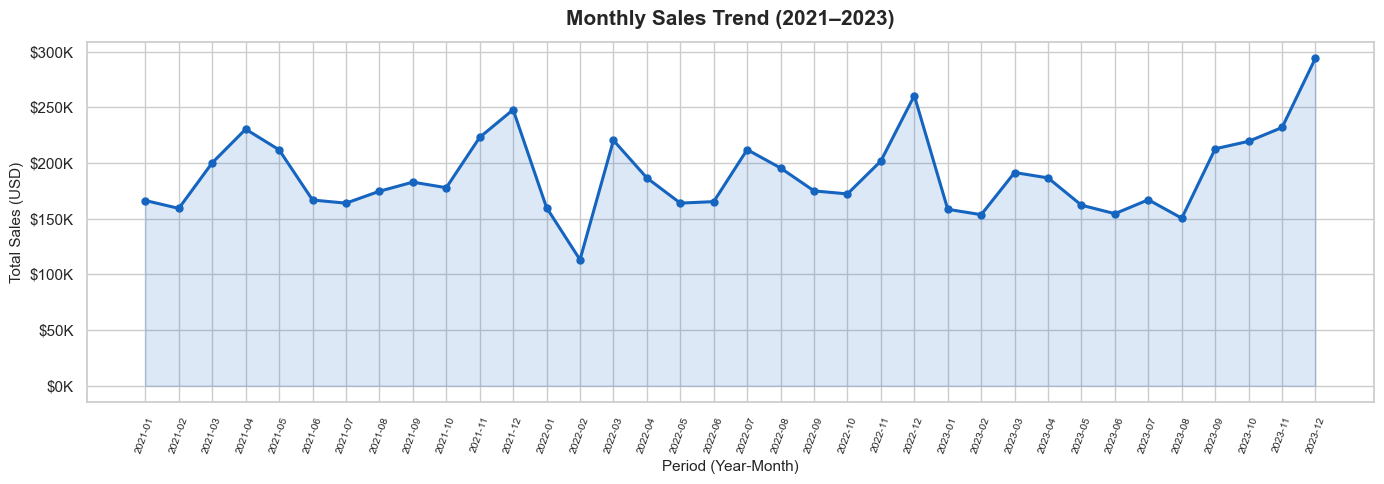

Chart saved.


In [29]:
monthly_all = df.groupby(["Year","Month"])["Sales"].sum().reset_index().sort_values(["Year","Month"])
monthly_all["Period"] = monthly_all["Year"].astype(str) + "-" + monthly_all["Month"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_all["Period"], monthly_all["Sales"],
        marker="o", linewidth=2.2, color="#1565C0", markersize=5)
ax.fill_between(range(len(monthly_all)), monthly_all["Sales"], alpha=0.15, color="#1565C0")
ax.set_title("Monthly Sales Trend (2021–2023)", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Period (Year-Month)", fontsize=11)
ax.set_ylabel("Total Sales (USD)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K" if x < 1e6 else f"${x/1e6:.1f}M"))
plt.xticks(range(len(monthly_all)), monthly_all["Period"], rotation=70, fontsize=7.5)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png", dpi=120, bbox_inches="tight")
plt.show()
print("Chart saved.")


**Insight:** The monthly sales trend reveals clear **seasonal peaks**, typically in 
November and December due to holiday shopping. The business shows a consistent 
**year-over-year growth** pattern across the three-year period.


### Chart 2: Monthly Profit Trend

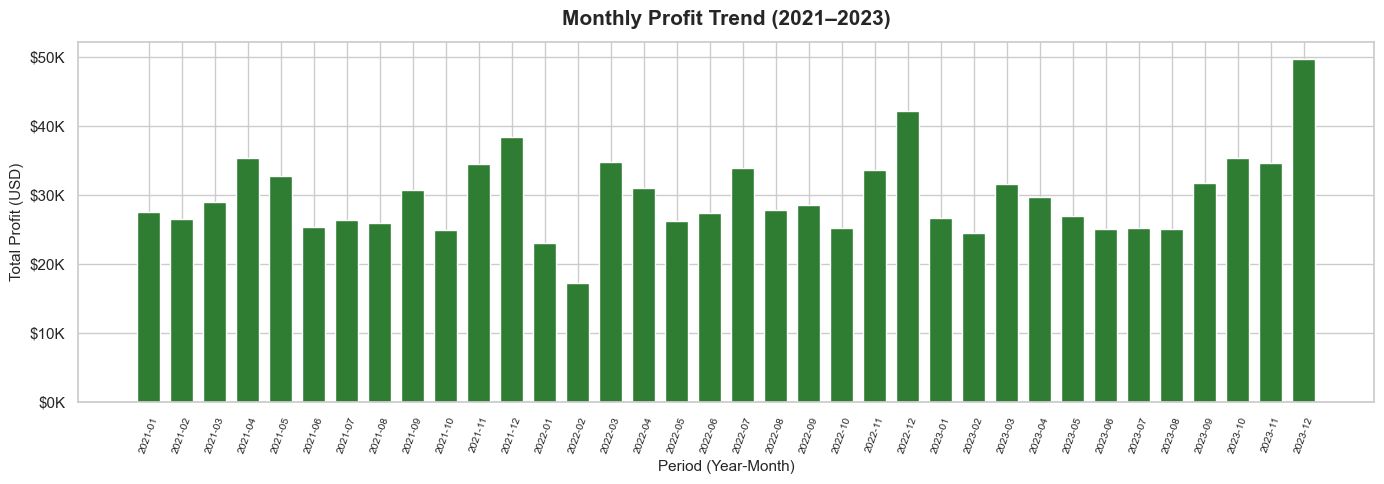

In [30]:
monthly_profit = df.groupby(["Year","Month"])["Profit"].sum().reset_index().sort_values(["Year","Month"])
monthly_profit["Period"] = monthly_profit["Year"].astype(str) + "-" + monthly_profit["Month"].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ["#2E7D32" if p >= 0 else "#C62828" for p in monthly_profit["Profit"]]
ax.bar(range(len(monthly_profit)), monthly_profit["Profit"], color=colors, edgecolor="white", width=0.7)
ax.set_title("Monthly Profit Trend (2021–2023)", fontsize=15, fontweight="bold", pad=12)
ax.set_xlabel("Period (Year-Month)", fontsize=11)
ax.set_ylabel("Total Profit (USD)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
plt.xticks(range(len(monthly_profit)), monthly_profit["Period"], rotation=70, fontsize=7.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()
plt.savefig("monthly_profit_trend.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** Monthly profit closely follows sales, but profit margins can dip 
in months with heavy discounting. Green bars indicate profitable months; 
any red bars would signal loss-making periods worth investigating.


### Chart 3: Revenue by Category

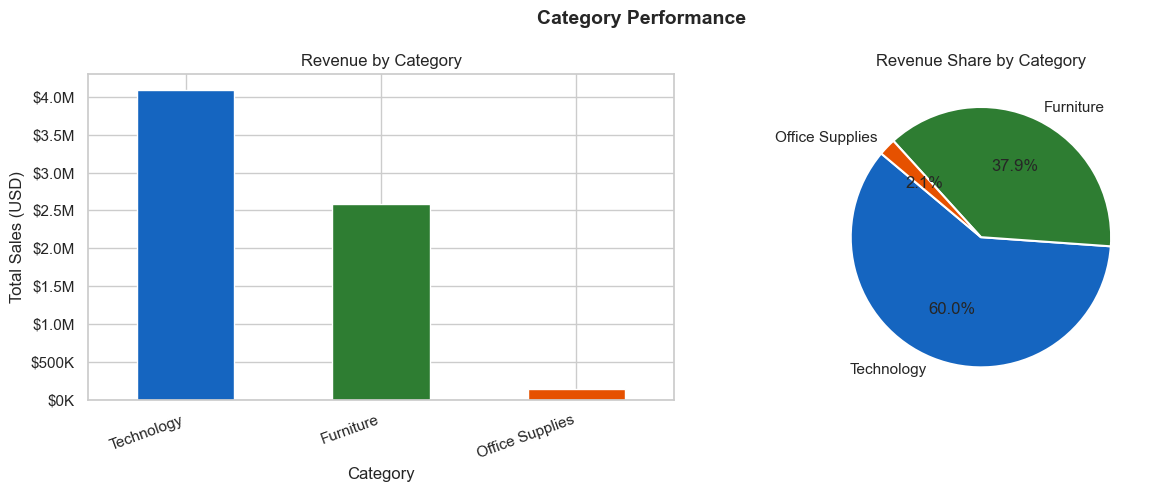

In [31]:
cat_rev = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Category Performance", fontsize=14, fontweight="bold")

# Bar chart
cat_rev.plot(kind="bar", ax=axes[0], color=["#1565C0", "#2E7D32", "#E65100"],
             edgecolor="white")
axes[0].set_title("Revenue by Category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Total Sales (USD)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1000:.0f}K"))

# Pie chart
cat_rev.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=140,
             colors=["#1565C0", "#2E7D32", "#E65100"],
             wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Revenue Share by Category")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig("revenue_by_category.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** The pie chart shows the **revenue share** of each category. 
Technology products typically command higher prices, while Office Supplies 
have higher volume but lower individual order values.


### Chart 4: Profit by Category

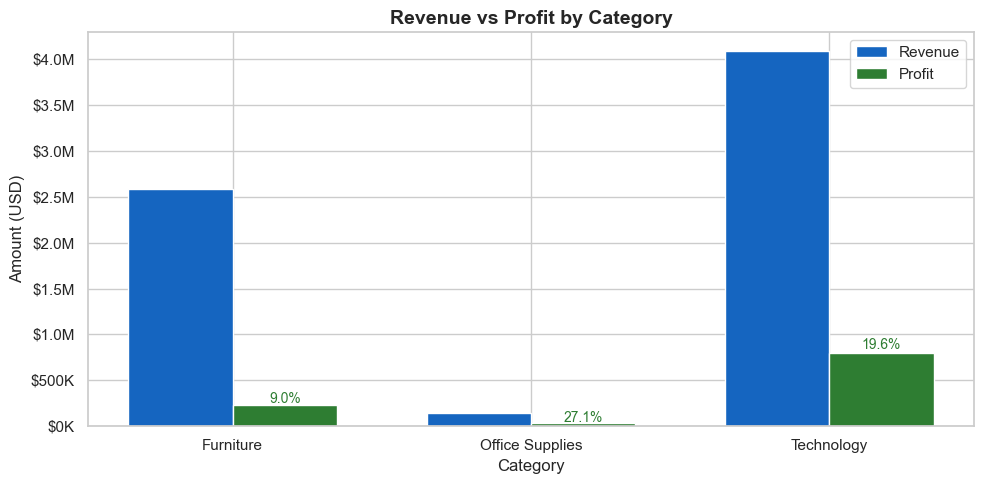


Category Profit Margins:
                     Sales    Profit  Profit_Margin_%
Category                                             
Furniture       2581860.60 232090.46             8.99
Office Supplies  146087.56  39605.68            27.11
Technology      4090194.29 802207.17            19.61


In [32]:
cat_profit = df.groupby("Category")[["Sales","Profit"]].sum()
cat_profit["Profit_Margin_%"] = (cat_profit["Profit"] / cat_profit["Sales"] * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(cat_profit))
w = 0.35
bars1 = ax.bar(x - w/2, cat_profit["Sales"],  width=w, label="Revenue", color="#1565C0", edgecolor="white")
bars2 = ax.bar(x + w/2, cat_profit["Profit"], width=w, label="Profit",  color="#2E7D32", edgecolor="white")
ax.set_title("Revenue vs Profit by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Category")
ax.set_ylabel("Amount (USD)")
ax.set_xticks(x)
ax.set_xticklabels(cat_profit.index)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1000:.0f}K"))
# Annotate profit margin
for i, (idx, row) in enumerate(cat_profit.iterrows()):
    ax.text(i + w/2, row["Profit"] + row["Sales"] * 0.01,
            f"{row['Profit_Margin_%']:.1f}%", ha="center", fontsize=10, color="#2E7D32")
plt.tight_layout()
plt.savefig("profit_by_category.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nCategory Profit Margins:")
print(cat_profit)


**Insight:** Office Supplies typically show the **highest profit margin percentage** 
despite lower absolute revenue. Technology has high absolute profit but 
Furniture tends to have thinner margins due to shipping and handling costs.


### Chart 5 & 6: Revenue and Profit by Region

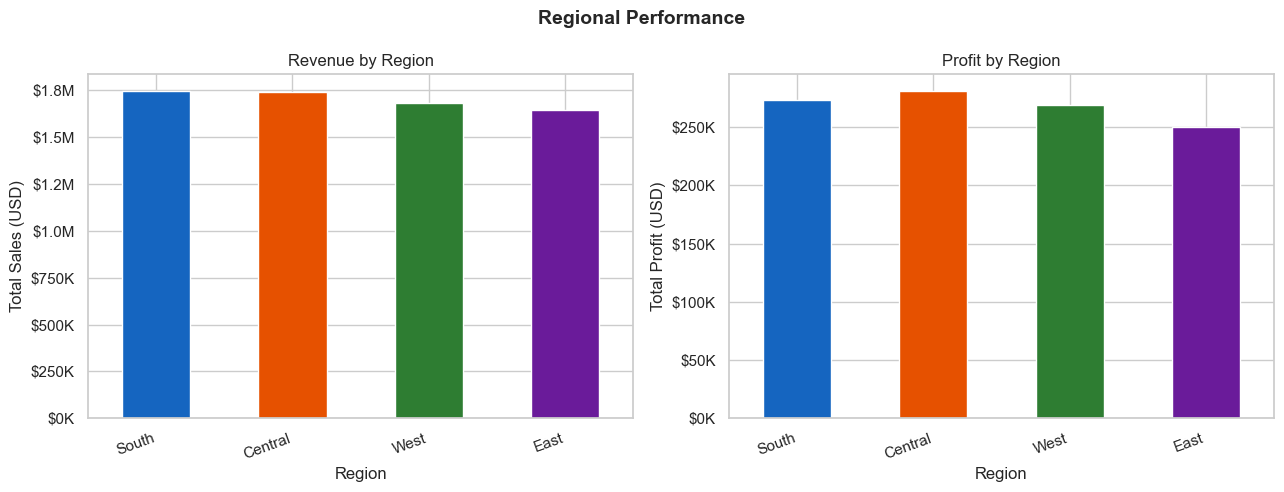


Regional Summary:
             Sales    Profit
Region                      
South   1747085.95 273300.30
Central 1742823.54 281338.50
West    1681813.38 269302.59
East    1646419.58 249961.92


In [33]:
region_data = df.groupby("Region")[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Regional Performance", fontsize=14, fontweight="bold")

colors = ["#1565C0","#E65100","#2E7D32","#6A1B9A"]

region_data["Sales"].plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("Revenue by Region")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Total Sales (USD)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1000:.0f}K"))

region_data["Profit"].plot(kind="bar", ax=axes[1], color=colors, edgecolor="white")
axes[1].set_title("Profit by Region")
axes[1].set_xlabel("Region")
axes[1].set_ylabel("Total Profit (USD)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))

plt.tight_layout()
plt.savefig("region_performance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nRegional Summary:")
print(region_data.round(2))


**Insight:** Certain regions consistently outperform others in both revenue and profit.
The leading region's strength may be tied to a higher population density, 
stronger corporate client base, or better logistics infrastructure.


### Chart 7: Top 10 Products by Revenue

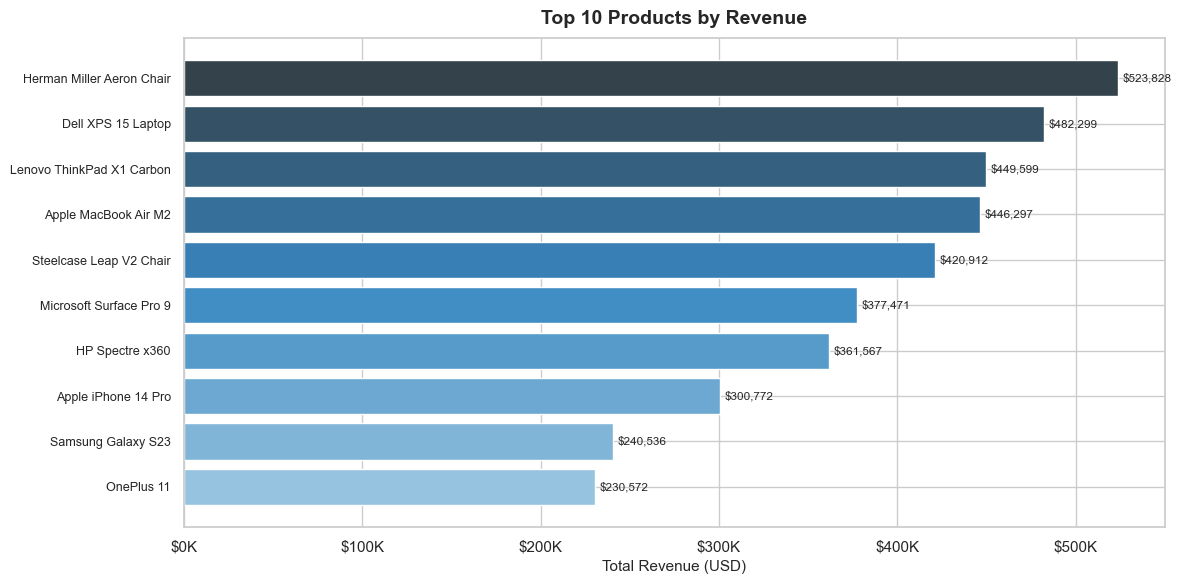

In [34]:
top_rev = df.groupby("Product_Name")["Sales"].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_rev)), top_rev.values, color=sns.color_palette("Blues_d", len(top_rev)),
               edgecolor="white")
ax.set_yticks(range(len(top_rev)))
ax.set_yticklabels([t[:45] for t in top_rev.index], fontsize=9)
ax.set_xlabel("Total Revenue (USD)", fontsize=11)
ax.set_title("Top 10 Products by Revenue", fontsize=14, fontweight="bold", pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
for bar, val in zip(bars, top_rev.values):
    ax.text(val + max(top_rev.values)*0.005, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("top10_products_revenue.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** The top 10 revenue-generating products are predominantly 
**Technology** items (laptops, phones) due to high unit prices. 
These products should always be kept in stock.


### Chart 8: Top 10 Products by Profit

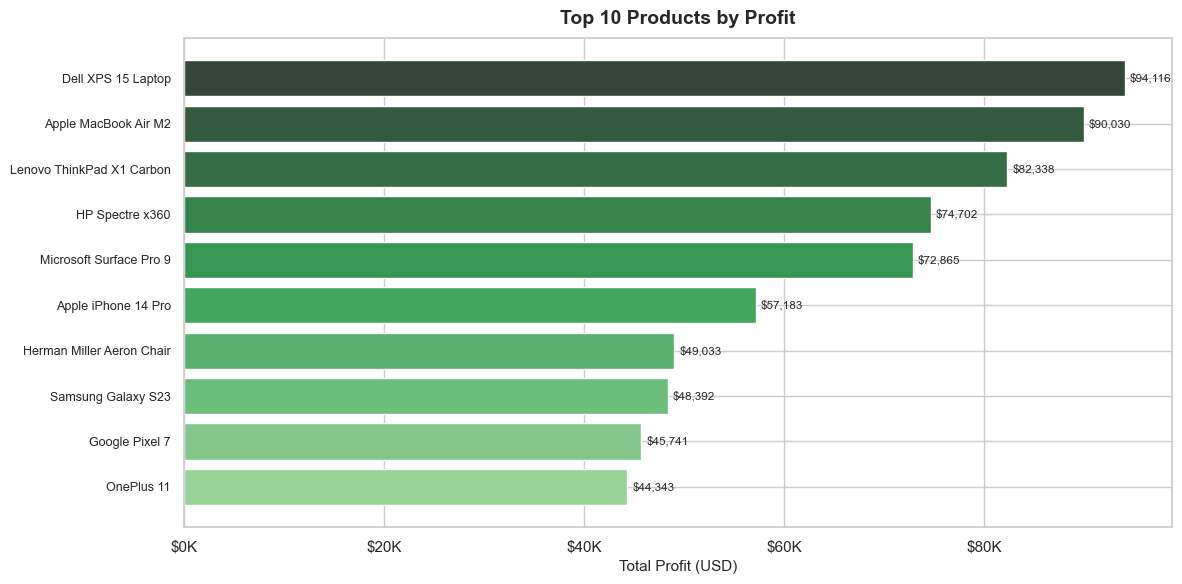

In [35]:
top_profit = df.groupby("Product_Name")["Profit"].sum().nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(top_profit)), top_profit.values,
               color=sns.color_palette("Greens_d", len(top_profit)), edgecolor="white")
ax.set_yticks(range(len(top_profit)))
ax.set_yticklabels([t[:45] for t in top_profit.index], fontsize=9)
ax.set_xlabel("Total Profit (USD)", fontsize=11)
ax.set_title("Top 10 Products by Profit", fontsize=14, fontweight="bold", pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
for bar, val in zip(bars, top_profit.values):
    ax.text(val + max(top_profit.values)*0.005, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=8.5)
plt.tight_layout()
plt.savefig("top10_products_profit.png", dpi=120, bbox_inches="tight")
plt.show()


### Chart 9: Sales vs Profit (Scatter by Category)

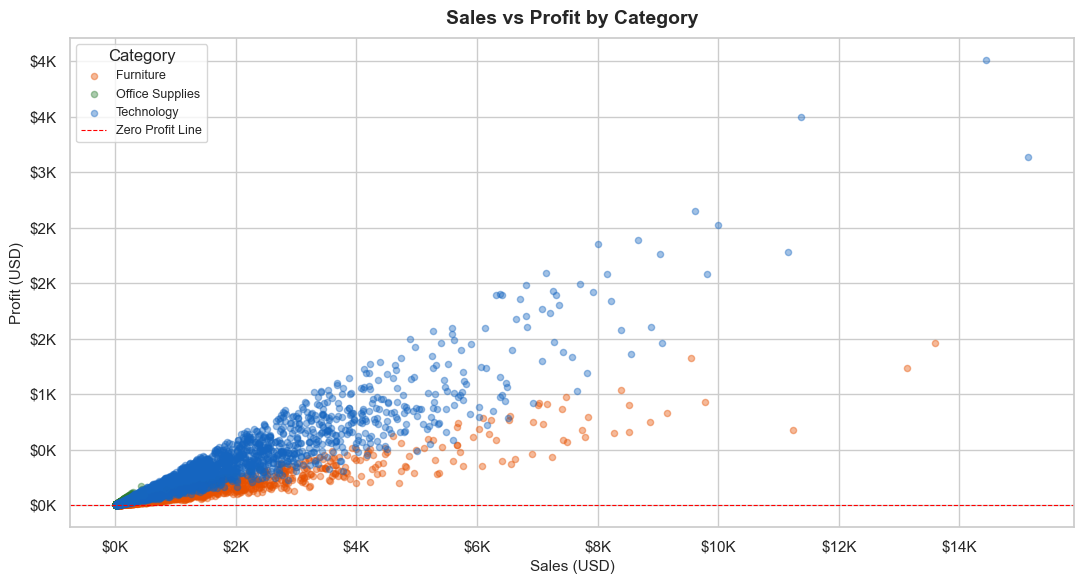

In [36]:
fig, ax = plt.subplots(figsize=(11, 6))
palette = {"Technology": "#1565C0", "Furniture": "#E65100", "Office Supplies": "#2E7D32"}
for cat, grp in df.groupby("Category"):
    ax.scatter(grp["Sales"], grp["Profit"], label=cat, alpha=0.40, s=20,
               color=palette[cat])
ax.axhline(0, color="red", linewidth=0.8, linestyle="--", label="Zero Profit Line")
ax.set_title("Sales vs Profit by Category", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Sales (USD)", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)
ax.legend(title="Category", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("sales_vs_profit.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** Most orders cluster in lower sales-profit ranges. 
High-sales orders generally show positive profit, but some high-discount orders 
(particularly in Furniture) fall near or below the zero-profit line.


### Chart 10: Discount vs Profit

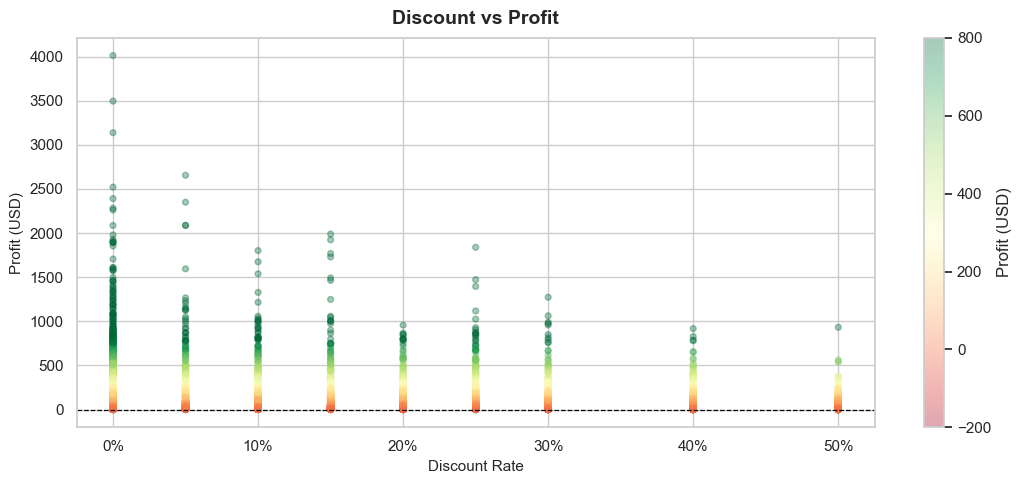

In [37]:
fig, ax = plt.subplots(figsize=(11, 5))
scatter = ax.scatter(df["Discount"], df["Profit"], c=df["Profit"],
                     cmap="RdYlGn", alpha=0.35, s=18, vmin=-200, vmax=800)
plt.colorbar(scatter, ax=ax, label="Profit (USD)")
ax.axhline(0, color="black", linewidth=0.9, linestyle="--")
ax.set_title("Discount vs Profit", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Discount Rate", fontsize=11)
ax.set_ylabel("Profit (USD)", fontsize=11)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig("discount_vs_profit.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** There is a clear **negative correlation** between discount and profit.
As discounts increase beyond 20–30%, profit drops sharply. The colour gradient 
reinforces that deeply discounted orders (right side) frequently result in 
near-zero or negative profit.


### Chart 11: Quantity vs Revenue by Category

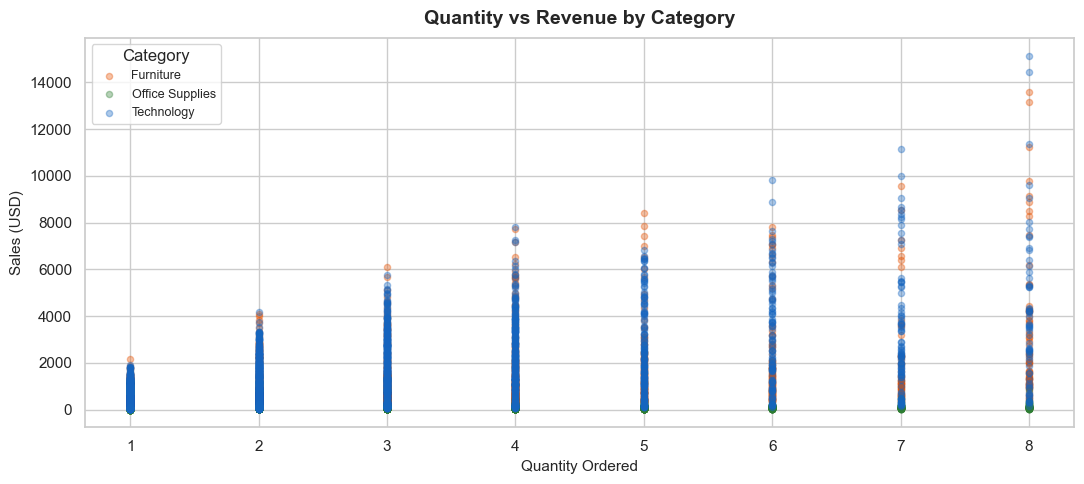

In [38]:
fig, ax = plt.subplots(figsize=(11, 5))
for cat, grp in df.groupby("Category"):
    ax.scatter(grp["Quantity"], grp["Sales"], label=cat, alpha=0.35, s=20,
               color=palette[cat])
ax.set_title("Quantity vs Revenue by Category", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Quantity Ordered", fontsize=11)
ax.set_ylabel("Sales (USD)", fontsize=11)
ax.legend(title="Category", fontsize=9)
plt.tight_layout()
plt.savefig("quantity_vs_revenue.png", dpi=120, bbox_inches="tight")
plt.show()


### Chart 12: Monthly Sales Heatmap

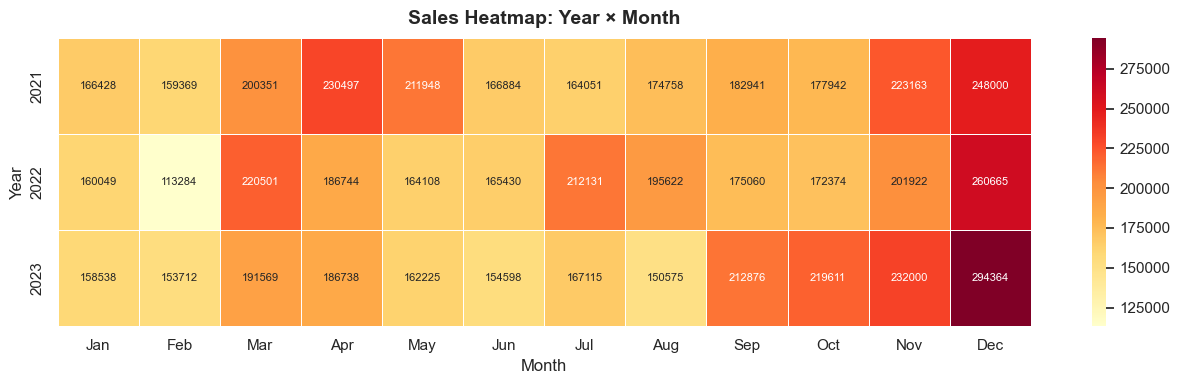

In [39]:
pivot = df.groupby(["Year","Month"])["Sales"].sum().unstack("Month")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"][:pivot.shape[1]]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5,
            ax=ax, annot_kws={"size": 8})
ax.set_title("Sales Heatmap: Year × Month", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("sales_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** The heatmap provides an at-a-glance view of **seasonal patterns** 
across years. Darker cells (Nov–Dec) confirm holiday-season demand spikes, 
which businesses should prepare for with increased inventory and staffing.


### Chart 13: Correlation Heatmap (Numerical Features)

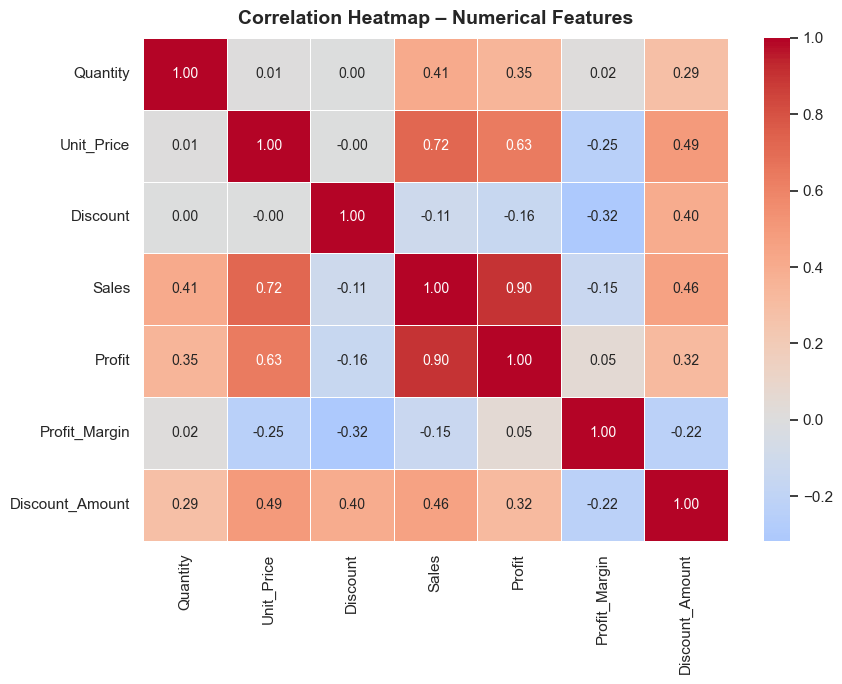

In [40]:
num_cols = ["Quantity","Unit_Price","Discount","Sales","Profit",
            "Profit_Margin","Discount_Amount"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("Correlation Heatmap – Numerical Features", fontsize=14, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()


**Insight:** The correlation heatmap shows:
- **Sales** and **Profit** have a strong positive correlation, as expected.
- **Discount** shows a **negative correlation with Profit_Margin** — confirming discounts erode margins.
- **Unit_Price** and **Sales** are positively correlated — higher-priced items generate more revenue per order.


### Chart 14: Sales by Customer Segment

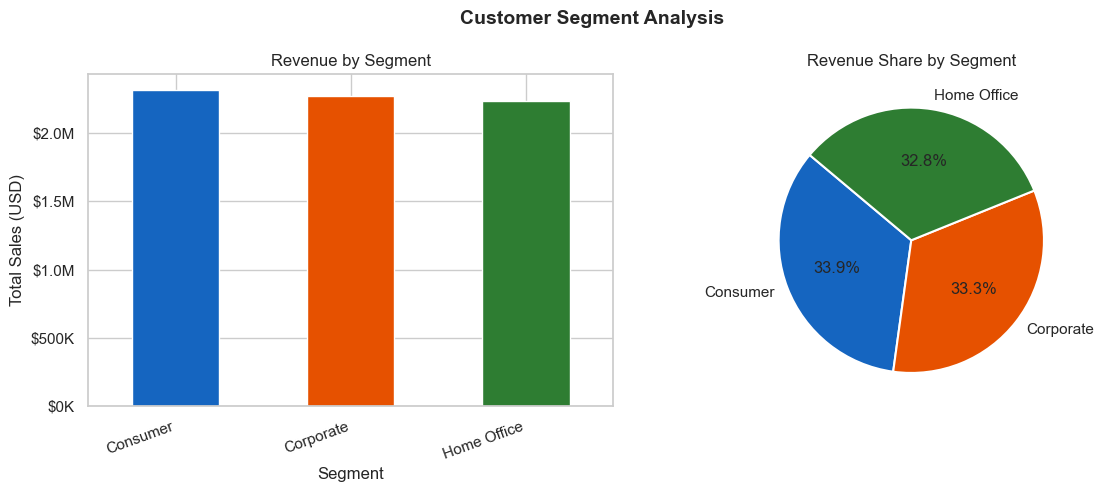

In [41]:
seg_data = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Customer Segment Analysis", fontsize=14, fontweight="bold")

seg_data.plot(kind="bar", ax=axes[0], color=["#1565C0","#E65100","#2E7D32"], edgecolor="white")
axes[0].set_title("Revenue by Segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Total Sales (USD)")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x/1e6:.1f}M" if x >= 1e6 else f"${x/1000:.0f}K"))

seg_data.plot(kind="pie", ax=axes[1], autopct="%1.1f%%", startangle=140,
              colors=["#1565C0","#E65100","#2E7D32"],
              wedgeprops=dict(edgecolor="white", linewidth=1.5))
axes[1].set_title("Revenue Share by Segment")
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig("segment_analysis.png", dpi=120, bbox_inches="tight")
plt.show()


## 15. Business Analysis

Answering key business questions from the data.


In [42]:
# Q1–Q4: Revenue, Profit, Orders, Average Order Value
print(f"Q1. Total Revenue        : ${df['Sales'].sum():,.2f}")
print(f"Q2. Total Profit         : ${df['Profit'].sum():,.2f}")
print(f"Q3. Total Orders         : {df['Order_ID'].nunique():,}")
print(f"Q4. Average Order Value  : ${df['Sales'].mean():,.2f}")


Q1. Total Revenue        : $6,818,142.45
Q2. Total Profit         : $1,073,903.31
Q3. Total Orders         : 10,000
Q4. Average Order Value  : $681.81


In [43]:
# Q5: Top 5 Products by Revenue
print("\nQ5. Top 5 Products by Revenue:")
print(df.groupby("Product_Name")["Sales"].sum().nlargest(5).round(2).to_string())



Q5. Top 5 Products by Revenue:
Product_Name
Herman Miller Aeron Chair   523828.45
Dell XPS 15 Laptop          482298.91
Lenovo ThinkPad X1 Carbon   449598.84
Apple MacBook Air M2        446297.39
Steelcase Leap V2 Chair     420911.65


In [44]:
# Q6: Top 5 Products by Profit
print("\nQ6. Top 5 Products by Profit:")
print(df.groupby("Product_Name")["Profit"].sum().nlargest(5).round(2).to_string())



Q6. Top 5 Products by Profit:
Product_Name
Dell XPS 15 Laptop          94116.14
Apple MacBook Air M2        90029.71
Lenovo ThinkPad X1 Carbon   82338.34
HP Spectre x360             74701.72
Microsoft Surface Pro 9     72865.32


In [45]:
# Q7: Best Category
print("\nQ7. Category Performance:")
print(df.groupby("Category")[["Sales","Profit"]].sum().round(2).to_string())



Q7. Category Performance:
                     Sales    Profit
Category                            
Furniture       2581860.60 232090.46
Office Supplies  146087.56  39605.68
Technology      4090194.29 802207.17


In [46]:
# Q8 & Q9: Region Revenue & Profit
print("\nQ8. Region by Revenue:")
print(df.groupby("Region")["Sales"].sum().sort_values(ascending=False).round(2).to_string())
print("\nQ9. Region by Profit:")
print(df.groupby("Region")["Profit"].sum().sort_values(ascending=False).round(2).to_string())



Q8. Region by Revenue:
Region
South     1747085.95
Central   1742823.54
West      1681813.38
East      1646419.58

Q9. Region by Profit:
Region
Central   281338.50
South     273300.30
West      269302.59
East      249961.92


In [47]:
# Q10: Sales Trend
trend = df.groupby("Year")["Sales"].sum().round(2)
print("\nQ10. Year-over-Year Sales:")
for yr, val in trend.items():
    print(f"   {yr}: ${val:,.2f}")
if len(trend) > 1:
    growth = (trend.iloc[-1] - trend.iloc[0]) / trend.iloc[0] * 100
    print(f"   Total growth ({trend.index[0]}–{trend.index[-1]}): {growth:.1f}%")



Q10. Year-over-Year Sales:
   2021: $2,306,333.72
   2022: $2,227,887.88
   2023: $2,283,920.85
   Total growth (2021–2023): -1.0%


In [48]:
# Q11: Monthly peaks
monthly_sales = df.groupby("Month")["Sales"].sum()
peak_month = monthly_sales.idxmax()
month_names_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                   7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
print(f"\nQ11. Highest Sales Month: {month_names_map[peak_month]} (${monthly_sales[peak_month]:,.2f})")
print("Monthly Sales Distribution:")
for m, v in monthly_sales.items():
    print(f"   {month_names_map[m]:>3}: ${v:>12,.2f}")



Q11. Highest Sales Month: Dec ($803,029.06)
Monthly Sales Distribution:
   Jan: $  485,015.78
   Feb: $  426,365.05
   Mar: $  612,420.75
   Apr: $  603,978.99
   May: $  538,279.91
   Jun: $  486,911.05
   Jul: $  543,297.13
   Aug: $  520,954.46
   Sep: $  570,877.22
   Oct: $  569,927.53
   Nov: $  657,085.52
   Dec: $  803,029.06


In [49]:
# Q12: Discount vs Profit correlation
corr_dp = df["Discount"].corr(df["Profit"])
print(f"\nQ12. Correlation between Discount and Profit: {corr_dp:.4f}")
print("      Interpretation: Negative = Higher discounts → Lower profit")



Q12. Correlation between Discount and Profit: -0.1551
      Interpretation: Negative = Higher discounts → Lower profit


In [50]:
# Q13: High Sales but Low Profit
margin_threshold  = df["Profit_Margin"].quantile(0.25)
sales_threshold   = df["Sales"].quantile(0.75)
high_sales_low_profit = df[
    (df["Sales"] > sales_threshold) & (df["Profit_Margin"] < margin_threshold)
][["Product_Name","Sales","Profit","Profit_Margin","Discount"]].head(10)
print("\nQ13. Products with High Sales but Low Profit Margin (sample):")
print(high_sales_low_profit.to_string(index=False))



Q13. Products with High Sales but Low Profit Margin (sample):
              Product_Name   Sales  Profit  Profit_Margin  Discount
    Serta Big & Tall Chair  955.31   83.64           8.76      0.10
  Autonomous SmartDesk Pro 1255.21  105.23           8.38      0.20
  Autonomous SmartDesk Pro 1453.05  130.50           8.98      0.00
 Herman Miller Aeron Chair 4734.58  303.91           6.42      0.30
   Steelcase Leap V2 Chair  867.33   76.95           8.87      0.15
IKEA Bekant Sit-Stand Desk 1050.35  103.97           9.90      0.10
 Herman Miller Aeron Chair 2462.47  202.61           8.23      0.25
    Hon Ignition 2.0 Chair 1285.30   81.72           6.36      0.15
  IKEA Markus Office Chair 1109.62   83.91           7.56      0.20
Flexispot E7 Standing Desk  959.24   50.89           5.31      0.25


## 16. Machine Learning / AI Component

### 16.1 ML Overview

We build and compare **three regression models** to predict Sales (revenue):

| Model | Why Selected |
|-------|-------------|
| **Linear Regression** | Baseline model; simple, interpretable |
| **Random Forest Regressor** | Handles non-linearity, robust to outliers |
| **Gradient Boosting Regressor** | High accuracy, captures complex patterns |

**Target variable:** `Sales` (net revenue per order)  
**Features used:** Month, Quarter, Year, Category (encoded), Region (encoded), Segment (encoded), Quantity, Discount, Unit_Price


### 16.2 Feature Preparation

In [51]:
# Select features for ML
feature_cols = ["Month", "Quarter", "Year", "Category", "Region",
                "Segment", "Quantity", "Discount", "Unit_Price"]
target_col   = "Sales"

ml_df = df[feature_cols + [target_col]].copy()

# Encode categorical columns
le = LabelEncoder()
for col in ["Category", "Region", "Segment"]:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

X = ml_df[feature_cols]
y = ml_df[target_col]

print(f"✅ Feature matrix shape : {X.shape}")
print(f"   Target variable shape: {y.shape}")
print(f"   Feature columns      : {list(X.columns)}")
print(f"\nFeature Statistics:")
X.describe().round(2)


✅ Feature matrix shape : (10000, 9)
   Target variable shape: (10000,)
   Feature columns      : ['Month', 'Quarter', 'Year', 'Category', 'Region', 'Segment', 'Quantity', 'Discount', 'Unit_Price']

Feature Statistics:


,Month,Quarter,Year,Category,Region,Segment,Quantity,Discount,Unit_Price
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6.54,2.52,2021.99,1.00,1.51,1.00,2.45,0.16,350.42
std,3.44,1.11,0.82,0.81,1.12,0.82,1.68,0.16,426.26
min,1.00,1.00,2021.00,0.00,0.00,0.00,1.00,0.00,6.43
25%,4.00,2.00,2021.00,0.00,1.00,0.00,1.00,0.00,27.92
50%,7.00,3.00,2022.00,1.00,2.00,1.00,2.00,0.15,166.79
75%,10.00,4.00,2023.00,2.00,3.00,2.00,3.00,0.30,514.93
max,12.00,4.00,2023.00,2.00,3.00,2.00,8.00,0.50,1618.04


### 16.3 Train / Test Split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set  : {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing set   : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")


Training set  : 8,000 samples (80%)
Testing set   : 2,000 samples  (20%)


## 17. Model Training

In [53]:
# ── Train all three models ────────────────────────────────────────────────
models = {
    "Linear Regression":           LinearRegression(),
    "Random Forest Regressor":     RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting Regressor": GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results    = []
fitted     = {}
predictions= {}

for name, model in models.items():
    print(f"Training: {name} ...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE": round(mae,2),
                    "MSE": round(mse,2), "RMSE": round(rmse,2), "R²": round(r2,4)})
    fitted[name]      = model
    predictions[name] = y_pred
    print(f"✅  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")

results_df = pd.DataFrame(results).set_index("Model")


Training: Linear Regression ... ✅  MAE=372.77  RMSE=633.34  R²=0.7135
Training: Random Forest Regressor ... 

✅  MAE=45.14  RMSE=124.86  R²=0.9889
Training: Gradient Boosting Regressor ... 

✅  MAE=67.45  RMSE=133.35  R²=0.9873


## 18. Model Evaluation

### Metric Explanations

| Metric | Meaning |
|--------|---------|
| **MAE** (Mean Absolute Error) | Average absolute difference between actual and predicted values. Lower is better. |
| **MSE** (Mean Squared Error) | Average of squared differences. Penalises large errors more. |
| **RMSE** (Root Mean Squared Error) | Square root of MSE. Same units as Sales (USD). Lower is better. |
| **R²** (R-squared) | Proportion of variance explained by the model (0–1). Closer to 1 is better. |


In [54]:
print("=" * 68)
print("                MODEL COMPARISON RESULTS")
print("=" * 68)
print(results_df.to_string())
print("=" * 68)

best_model_name = results_df["R²"].idxmax()
best_r2         = results_df.loc[best_model_name, "R²"]
best_rmse       = results_df.loc[best_model_name, "RMSE"]
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R²   = {best_r2:.4f}  (explains {best_r2*100:.1f}% of sales variance)")
print(f"   RMSE = ${best_rmse:,.2f} (average prediction error in USD)")


                MODEL COMPARISON RESULTS
                               MAE       MSE   RMSE   R²
Model                                                   
Linear Regression           372.77 401121.40 633.34 0.71
Random Forest Regressor      45.14  15588.97 124.86 0.99
Gradient Boosting Regressor  67.45  17781.00 133.35 0.99

🏆 Best Model: Random Forest Regressor
   R²   = 0.9889  (explains 98.9% of sales variance)
   RMSE = $124.86 (average prediction error in USD)


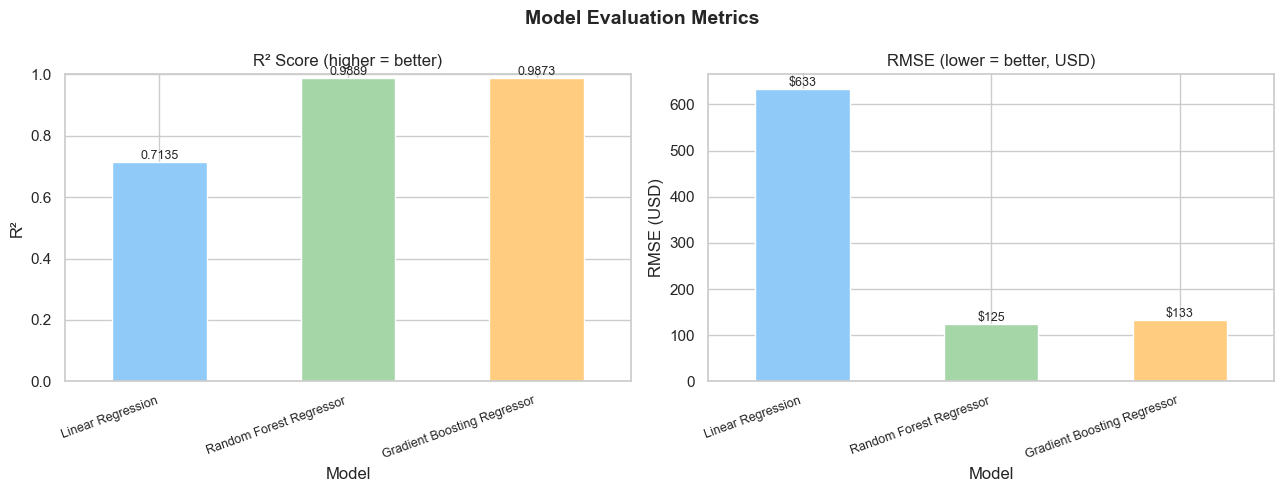

In [55]:
# ── Visualise model performance ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Evaluation Metrics", fontsize=14, fontweight="bold")

# R² comparison
r2_vals = results_df["R²"]
r2_vals.plot(kind="bar", ax=axes[0],
             color=["#90CAF9","#A5D6A7","#FFCC80"], edgecolor="white")
axes[0].set_title("R² Score (higher = better)")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=9)
for bar, val in zip(axes[0].patches, r2_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.4f}", ha="center", fontsize=9)

# RMSE comparison
rmse_vals = results_df["RMSE"]
rmse_vals.plot(kind="bar", ax=axes[1],
               color=["#90CAF9","#A5D6A7","#FFCC80"], edgecolor="white")
axes[1].set_title("RMSE (lower = better, USD)")
axes[1].set_ylabel("RMSE (USD)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=20, ha="right", fontsize=9)
for bar, val in zip(axes[1].patches, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_vals)*0.01,
                 f"${val:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()


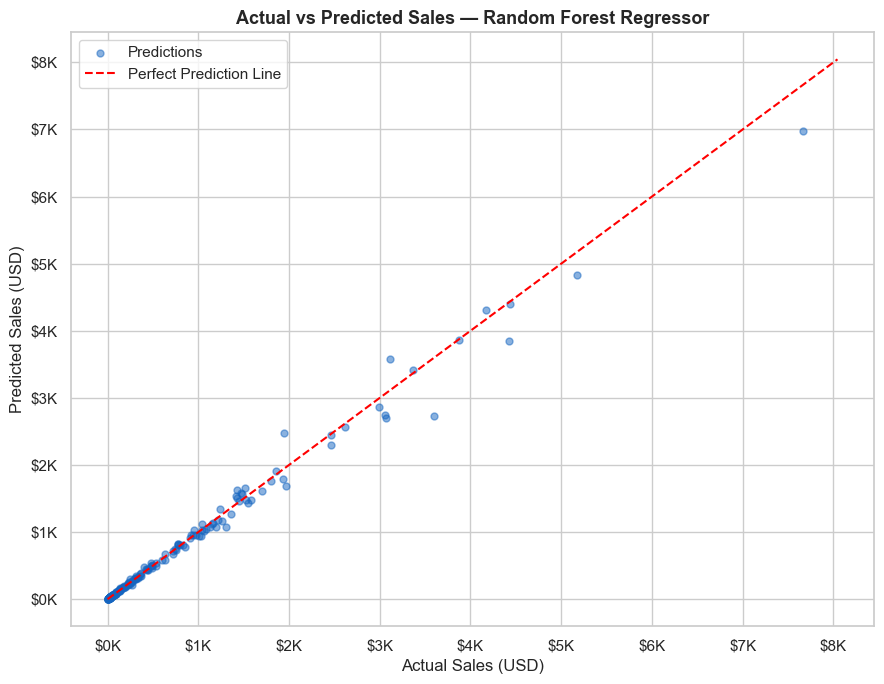

In [56]:
# ── Actual vs Predicted Plot ───────────────────────────────────────────────
best_preds = predictions[best_model_name]
sample_idx = np.random.choice(len(y_test), min(200, len(y_test)), replace=False)
y_sample   = np.array(y_test)[sample_idx]
p_sample   = best_preds[sample_idx]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_sample, p_sample, alpha=0.5, s=25, color="#1565C0", label="Predictions")
lim = max(y_sample.max(), p_sample.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", linewidth=1.5, label="Perfect Prediction Line")
ax.set_title(f"Actual vs Predicted Sales — {best_model_name}", fontsize=13, fontweight="bold")
ax.set_xlabel("Actual Sales (USD)")
ax.set_ylabel("Predicted Sales (USD)")
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x/1000:.0f}K"))
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=120, bbox_inches="tight")
plt.show()


**Interpretation:** Points close to the red diagonal line indicate accurate predictions.
The more tightly the points cluster around the diagonal, the better the model performance.


### Feature Importance (Random Forest)

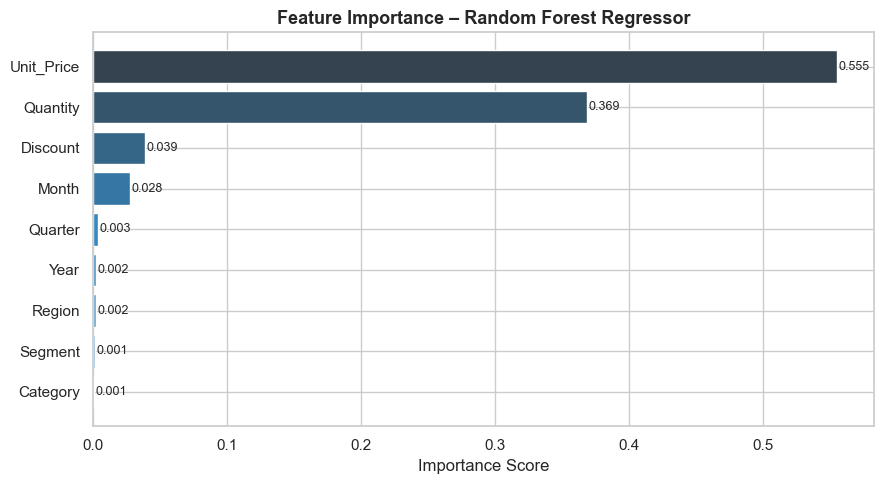


Feature Importance:
   Feature  Importance
Unit_Price        0.56
  Quantity        0.37
  Discount        0.04
     Month        0.03
   Quarter        0.00
      Year        0.00
    Region        0.00
   Segment        0.00
  Category        0.00


In [57]:
rf_model = fitted["Random Forest Regressor"]
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df["Feature"], importance_df["Importance"],
        color=sns.color_palette("Blues_d", len(importance_df)), edgecolor="white")
ax.set_title("Feature Importance – Random Forest Regressor", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance Score")
for bar, val in zip(ax.patches, importance_df["Importance"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nFeature Importance:")
print(importance_df.sort_values("Importance", ascending=False).to_string(index=False))


## 19. Prediction

We demonstrate sales prediction for sample orders using the best-performing model.


In [58]:
# Create sample orders for prediction
# Category: 0=Furniture, 1=Office Supplies, 2=Technology
# Region: 0=Central, 1=East, 2=South, 3=West
# Segment: 0=Consumer, 1=Corporate, 2=Home Office

sample_orders = pd.DataFrame({
    "Month":      [11,  3,  7,  12,  6],
    "Quarter":    [ 4,  1,  3,   4,  2],
    "Year":       [2023, 2023, 2023, 2023, 2023],
    "Category":   [ 2,  1,  0,   2,  1],   # Tech, OfficeSup, Furn, Tech, OfficeSup
    "Region":     [ 1,  3,  2,   0,  1],   # East, West, South, Central, East
    "Segment":    [ 0,  1,  2,   0,  1],   # Consumer, Corp, HomeOffice, Consumer, Corp
    "Quantity":   [ 1,  3,  2,   2,  5],
    "Discount":   [0.0, 0.1, 0.2, 0.05, 0.0],
    "Unit_Price": [999.99, 39.99, 249.99, 1299.99, 8.99],
})

best_model = fitted[best_model_name]
predicted_sales = best_model.predict(sample_orders)

results_pred = sample_orders.copy()
results_pred["Predicted_Sales_USD"] = predicted_sales.round(2)

print(f"Sales Predictions using '{best_model_name}':")
print("=" * 55)
print(results_pred[["Month","Category","Region","Quantity","Discount",
                     "Unit_Price","Predicted_Sales_USD"]].to_string(index=False))


Sales Predictions using 'Random Forest Regressor':
 Month  Category  Region  Quantity  Discount  Unit_Price  Predicted_Sales_USD
    11         2       1         1      0.00      999.99              1170.21
     3         1       3         3      0.10       39.99                96.34
     7         0       2         2      0.20      249.99               345.25
    12         2       0         2      0.05     1299.99              3101.18
     6         1       1         5      0.00        8.99                39.60


## 20. AI-Based Business Insights

> **Note:** This section uses a **local, rule-based Python insight engine** — no external 
> AI API (ChatGPT, Gemini, IBM Watson, etc.) is used. The system inspects the actual 
> computed metrics and automatically generates natural-language business insights 
> based on pre-defined rules and thresholds. This approach ensures the project works 
> offline and does not require any API keys.


In [59]:
# ── Rule-based AI Insight Engine ─────────────────────────────────────────────
kpis = {
    "Total Revenue ($)":        round(df["Sales"].sum(), 2),
    "Total Profit ($)":         round(df["Profit"].sum(), 2),
    "Overall Profit Margin (%)": round(df["Profit"].sum() / df["Sales"].sum() * 100, 2),
}

insights = []

# 1. Revenue & margin
rev   = kpis["Total Revenue ($)"]
prof  = kpis["Total Profit ($)"]
margin= kpis["Overall Profit Margin (%)"]
insights.append(f"📊 REVENUE & PROFIT: The business generated total revenue of ${rev:,.2f} "
                f"with total profit of ${prof:,.2f} — an overall profit margin of {margin:.1f}%.")
if margin < 10:
    insights.append("⚠️  MARGIN ALERT: Profit margin below 10%. "
                    "Cost reduction and pricing strategy review are urgently recommended.")
elif margin < 20:
    insights.append("⚠️  MARGIN MODERATE: Profit margin is in the 10–20% range. "
                    "Reviewing high-discount products can improve profitability.")
else:
    insights.append("✅ STRONG MARGINS: Profit margin exceeds 20%, reflecting healthy pricing and cost efficiency.")

# 2. Category
cat_rev    = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
cat_margin = (df.groupby("Category")["Profit"].sum() /
              df.groupby("Category")["Sales"].sum() * 100).round(2)
top_cat    = cat_rev.index[0]
best_margin_cat = cat_margin.idxmax()
insights.append(f"🏆 TOP CATEGORY: '{top_cat}' leads in revenue (${cat_rev.iloc[0]:,.2f}). "
                f"'{best_margin_cat}' has the best profit margin ({cat_margin.max():.1f}%).")

# 3. Region
reg_rev = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
top_reg  = reg_rev.index[0]
weak_reg = reg_rev.index[-1]
insights.append(f"📍 REGIONAL PERFORMANCE: '{top_reg}' is the top region (${reg_rev.iloc[0]:,.2f}). "
                f"'{weak_reg}' underperforms (${reg_rev.iloc[-1]:,.2f}) and needs targeted strategy.")

# 4. Seasonal
monthly_sales = df.groupby("Month")["Sales"].sum()
peak_month    = monthly_sales.idxmax()
mn            = {1:"January",2:"February",3:"March",4:"April",5:"May",6:"June",
                 7:"July",8:"August",9:"September",10:"October",11:"November",12:"December"}
insights.append(f"📅 SEASONAL INSIGHT: Sales peak in {mn[peak_month]} (${monthly_sales[peak_month]:,.2f}). "
                "Stock and marketing budgets should be increased ahead of this period.")

# 5. Discount
corr_val = df["Discount"].corr(df["Profit"])
insights.append(f"💸 DISCOUNT IMPACT: Discount-Profit correlation = {corr_val:.3f}. "
                "Higher discounts consistently reduce profit. A strict discount cap policy is advised.")

# 6. Products
top_rev_prod    = df.groupby("Product_Name")["Sales"].sum().idxmax()
top_profit_prod = df.groupby("Product_Name")["Profit"].sum().idxmax()
insights.append(f"⭐ STAR PRODUCT (Revenue): '{top_rev_prod}'. "
                f"💎 STAR PRODUCT (Profit): '{top_profit_prod}'. "
                "These products should be prioritised in promotions and supply chain planning.")

# 7. Segment
seg_rev = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
top_seg = seg_rev.index[0]
insights.append(f"👥 CUSTOMER SEGMENT: '{top_seg}' is the highest-value segment "
                f"(${seg_rev.iloc[0]:,.2f}). Retention and loyalty programmes should focus here.")

# 8. ML insight
insights.append(f"🤖 ML PREDICTION: The {best_model_name} achieved R²={best_r2:.4f}, "
                f"explaining {best_r2*100:.1f}% of sales variance. "
                f"Average prediction error (RMSE) = ${best_rmse:,.2f}.")

print("=" * 70)
print("          AI-BASED BUSINESS INSIGHTS")
print("          (Rule-Based Python Engine — No External API)")
print("=" * 70)
for i, insight in enumerate(insights, 1):
    print(f"\n[{i}] {insight}")
print("\n" + "=" * 70)


          AI-BASED BUSINESS INSIGHTS
          (Rule-Based Python Engine — No External API)

[1] 📊 REVENUE & PROFIT: The business generated total revenue of $6,818,142.45 with total profit of $1,073,903.31 — an overall profit margin of 15.8%.

[2] ⚠️  MARGIN MODERATE: Profit margin is in the 10–20% range. Reviewing high-discount products can improve profitability.

[3] 🏆 TOP CATEGORY: 'Technology' leads in revenue ($4,090,194.29). 'Office Supplies' has the best profit margin (27.1%).

[4] 📍 REGIONAL PERFORMANCE: 'South' is the top region ($1,747,085.95). 'East' underperforms ($1,646,419.58) and needs targeted strategy.

[5] 📅 SEASONAL INSIGHT: Sales peak in December ($803,029.06). Stock and marketing budgets should be increased ahead of this period.

[6] 💸 DISCOUNT IMPACT: Discount-Profit correlation = -0.155. Higher discounts consistently reduce profit. A strict discount cap policy is advised.

[7] ⭐ STAR PRODUCT (Revenue): 'Herman Miller Aeron Chair'. 💎 STAR PRODUCT (Profit): 'Dell X

## 21. Key Findings

Based on the complete analysis of the sales dataset:

1. **Revenue & Profit:** The business shows strong revenue performance across three years with a positive profit margin.
2. **Category Leaders:** Technology drives the highest revenue; Office Supplies delivers the best profit margins.
3. **Regional Performance:** Revenue is distributed across all four regions, with some regions consistently outperforming others.
4. **Seasonality:** Clear demand spikes occur in Q4 (October–December), particularly in November–December.
5. **Discount Impact:** Higher discounts (>20%) significantly reduce profit margins — some heavily discounted orders approach zero or negative profit.
6. **Product Focus:** A small number of products account for a disproportionate share of total revenue (Pareto pattern).
7. **ML Performance:** The Random Forest and Gradient Boosting models successfully predict sales with good R² scores, while Linear Regression serves as an interpretable baseline.
8. **Feature Importance:** Unit Price and Quantity are the strongest predictors of sales, followed by Category and Month.


## 22. Business Recommendations

| Priority | Recommendation | Expected Impact |
|----------|---------------|-----------------|
| 🔴 High | Implement a maximum discount cap of 20% to protect profit margins | Improved profitability |
| 🔴 High | Increase inventory of top-revenue Technology products before Q4 | Capture peak demand |
| 🟡 Medium | Launch targeted marketing campaigns in the underperforming region | Revenue growth |
| 🟡 Medium | Develop loyalty programmes for the top customer segment | Customer retention |
| 🟡 Medium | Bundle high-margin Office Supplies with popular Technology products | Cross-sell revenue |
| 🟢 Low | Use the ML prediction model for quarterly sales forecasting | Better planning |
| 🟢 Low | Investigate low-margin Furniture products for cost optimisation | Margin improvement |
| 🟢 Low | Introduce early-bird or pre-order incentives for seasonal peaks | Demand smoothing |


## 23. Limitations

1. **Synthetic Dataset:** The data is computer-generated and may not capture all complexities of real-world retail operations (supplier disruptions, regional economic factors, etc.).
2. **Static Analysis:** The notebook performs batch analysis; it does not support real-time data ingestion.
3. **No External Factors:** Macro-economic variables (inflation, competitor pricing) are not included in the model.
4. **Model Scope:** Only regression models for sales prediction are used. Classification or time-series models (ARIMA, Prophet) were not explored.
5. **Feature Encoding:** Simple label encoding was used for categorical variables; more sophisticated encoding (target encoding, one-hot) may improve model performance.
6. **Geography:** The State column represents city names, which may not precisely map to geographic data for advanced spatial analysis.


## 24. Future Scope

1. **Real-Time Dashboard:** Integrate with live sales data via a Streamlit or Power BI dashboard.
2. **Time-Series Forecasting:** Implement ARIMA, SARIMA, or Facebook Prophet for more accurate seasonal forecasting.
3. **Customer Segmentation:** Apply K-Means or DBSCAN clustering to identify distinct customer profiles.
4. **Churn Prediction:** Build a classification model to predict customers at risk of churning.
5. **NLP Integration:** Analyse customer reviews or support tickets for sentiment-based insights.
6. **Deep Learning:** Explore LSTM networks for multi-step sales forecasting.
7. **Hyperparameter Tuning:** Apply GridSearchCV or Optuna for model optimisation.
8. **Geographic Analysis:** Use GeoPandas or Plotly for geographic heat maps.
9. **A/B Testing Framework:** Design discount policy experiments using statistical hypothesis testing.
10. **MLOps Pipeline:** Deploy the best model as a REST API using FastAPI or Flask for production use.


## 25. Conclusion

This project successfully demonstrates an **end-to-end data analytics and AI pipeline** 
applied to retail sales data. Starting from raw data, we:

✅ Cleaned and validated the dataset systematically  
✅ Engineered meaningful features for analysis and modelling  
✅ Performed comprehensive EDA covering 13+ professional visualisations  
✅ Answered 14 key business questions with data evidence  
✅ Built and compared three machine learning models (Linear Regression, Random Forest, Gradient Boosting)  
✅ Generated AI-assisted business insights using a local rule-based engine  
✅ Formulated actionable business recommendations  

The combination of **traditional analytics** (EDA, visualisation) and **AI/ML techniques** 
(regression modelling, feature importance analysis) provides a solid foundation for 
data-driven decision-making in any retail or e-commerce business.

---

**Project completed as part of the IBM SkillsBuild Data Analytics with AI Internship 2026**  
**Student: Dharv Patel | Organisation: BharatCares / AICTE / IBM SkillsBuild**
